# EDA 06jul2026
### Imports necesarios para el EDA

In [1]:
import pandas as pd
from sqlalchemy import create_engine
from scipy.stats import chi2_contingency
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
from dotenv import load_dotenv

**NOTA**: Crear .env con variables MYSQL_PASSWORD, MYSQL_HOST, MYSQL_PORT, MYSQL_USER, MYSQL_DATABASE dentro de la propia carpeta SCRIPTS para reejectuar EDA.

El .env está incluido en .gitignore y no se copiará en el repositorio

### Conexión a la BBDD
 

In [2]:
load_dotenv(dotenv_path=".env") 
MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
MYSQL_HOST = os.getenv("MYSQL_HOST")
MYSQL_PORT = os.getenv("MYSQL_PORT")
MYSQL_USER = os.getenv("MYSQL_USER")
MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")

In [3]:
# Crear motor de conexión
engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
)

### Carga dataset
**NOTA**: cambiar nombre tabla para reejecutar semanalmente

In [4]:
table = "RRHH_CLEAN_07072026"

In [5]:
with engine.connect():
    query = f"SELECT * FROM {table};"
    df = pd.read_sql(query, engine)

### Dimensiones dataset

In [6]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 805
Columnas: 26


### Muestra del dataset

In [7]:
# Muestra de las cinco primeras filas del DataFrame
df.head()

,ID_Absence,ID_Employee,Reason_Absence,Reason_Absence_Desc,Month_Absence,Day_Week,Day_Week_Desc,Seasons,Season_Desc,Transportation_Expense,...,Education,Education_Desc,Son,Social_Drinker,Social_Smoker,Pet,Weight,Height,Body_Mass_Index,Absenteeism_Hours
0,0,14,11,Enfermedades del sistema digestivo,11,2,Lunes,4,Otoño,155.0,...,1,Educación secundaria,2,1,0,0,95,196,25,120
1,1,36,13,Enfermedades del sistema musculoesquelético,4,4,Miércoles,2,Primavera,118.0,...,1,Educación secundaria,1,1,0,0,98,178,31,120
2,2,9,6,Enfermedades del sistema nervioso,7,3,Martes,3,Verano,228.0,...,1,Educación secundaria,2,0,0,1,65,172,22,120
3,3,28,9,Enfermedades del sistema circulatorio,7,3,Martes,3,Verano,225.0,...,1,Educación secundaria,1,0,0,2,69,169,24,112
4,4,9,12,Enfermedades de la piel,3,3,Martes,2,Primavera,228.0,...,1,Educación secundaria,2,0,0,1,65,172,22,112


In [8]:
# Muestra de cinco filas aleatorias del DataFrame
df.sample(5, random_state=42) # random_state muestra mismas filas ejecutadas x primera vez

,ID_Absence,ID_Employee,Reason_Absence,Reason_Absence_Desc,Month_Absence,Day_Week,Day_Week_Desc,Seasons,Season_Desc,Transportation_Expense,...,Education,Education_Desc,Son,Social_Drinker,Social_Smoker,Pet,Weight,Height,Body_Mass_Index,Absenteeism_Hours
192,192,1,1,Enfermedades infecciosas y parasitarias,5,2,Lunes,2,Primavera,235.0,...,3,Postgrado,1,0,0,1,88,172,29,8
718,719,50,10,Enfermedades del sistema respiratorio,5,2,Lunes,2,Primavera,235.0,...,3,Postgrado,0,0,0,0,75,178,25,8
168,168,20,26,Ausencia injustificada,12,4,Miércoles,1,Invierno,260.0,...,1,Educación secundaria,4,1,0,0,65,168,23,8
522,522,28,23,Consulta médica,11,6,Viernes,4,Otoño,225.0,...,1,Educación secundaria,1,0,0,2,69,169,24,2
536,536,29,28,Consulta dental,2,6,Viernes,1,Invierno,225.0,...,4,Máster o doctorado,2,1,0,2,94,182,28,2


### Tipos de datos

In [9]:
tipos_datos = pd.DataFrame({
    "tipo_dato": df.dtypes.astype(str),
    "valores_unicos": df.nunique(),
    "valores_no_nulos": df.notna().sum(),
    "valores_nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100).round(2)
}).reset_index().rename(columns={"index": "columna"})

tipos_datos

,columna,tipo_dato,valores_unicos,valores_no_nulos,valores_nulos,porcentaje_nulos
0,ID_Absence,int64,805,805,0,0.0
1,ID_Employee,int64,136,805,0,0.0
2,Reason_Absence,int64,28,805,0,0.0
3,Reason_Absence_Desc,object,28,805,0,0.0
4,Month_Absence,int64,13,805,0,0.0
5,Day_Week,int64,5,805,0,0.0
6,Day_Week_Desc,object,5,805,0,0.0
7,Seasons,int64,5,805,0,0.0
8,Season_Desc,object,5,805,0,0.0
9,Transportation_Expense,float64,24,805,0,0.0


### Duplicados

In [10]:
duplicados_detalle = df[df.duplicated(keep=False)].sort_values(list(df.columns))
print(f"Registros involucrados en duplicados completos: {len(duplicados_detalle)}")
duplicados_detalle.head(10)

Registros involucrados en duplicados completos: 0


,ID_Absence,ID_Employee,Reason_Absence,Reason_Absence_Desc,Month_Absence,Day_Week,Day_Week_Desc,Seasons,Season_Desc,Transportation_Expense,...,Education,Education_Desc,Son,Social_Drinker,Social_Smoker,Pet,Weight,Height,Body_Mass_Index,Absenteeism_Hours


In [11]:
duplicados = df.duplicated().sum()

print(f"Filas duplicadas: {duplicados}")
print(f"Porcentaje duplicado: {duplicados / len(df) * 100:.2f}%")


Filas duplicadas: 0
Porcentaje duplicado: 0.00%


### Clasificación de variables en categórica y númericas ( discretas y continuas )

In [12]:
variables_categoricas = [
    'Reason_absence', 'Month_absence', 'Day_week', 'Seasons', 'Education'
]

variables_booleanas = ['Disciplinary_failure', 'Social_drinker', 'Social_smoker']

variables_discretas = ['Son', 'Pet' ]

variables_continuas = [
    'Transportation_expense', 'Distance_Residence_Work', 'Work_load_Average_day', 'Age', 
    'Hit_target', 'Weight', 'Height', 'Body_mass_index', 'Absenteeism_hours', 'Service_time'
]


### Conversiones de datos para facilitar el EDA

In [13]:
# Convertir las columnas "Son" y "Pet" a tipo int para que puedan ser utilizadas como numéricas.

df['Son'] = df['Son'].astype(int)
df['Pet'] = df['Pet'].astype(int)


# Convertir la columna "Work_load_Average_day" a tipo float para que pueda ser utilizada como númerica.

df["Work_load_Average_day"] = (
    df["Work_load_Average_day"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# Convertir las columnas categóricas a tipo "category".

for col in variables_categoricas:
    df[col] = df[col].astype("category")

KeyError: 'Work_load_Average_day'

### Analisis Estadístico 

#### Variables númericas

In [ ]:
variables_numericas = variables_discretas + variables_continuas

df[variables_numericas].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Son,845.0,1.02,1.10,0.00,0.00,1.00,2.00,4.00
Pet,845.0,0.74,1.31,0.00,0.00,0.00,1.00,8.00
Transportation_expense,845.0,221.24,67.61,118.00,179.00,225.00,260.00,388.00
Distance_Residence_Work,845.0,29.46,14.81,5.00,16.00,26.00,49.00,52.00
Work_load_Average_day,845.0,270.85,38.73,205.92,244.39,264.25,284.85,378.88
Age,845.0,36.52,6.61,27.00,31.00,37.00,40.00,58.00
Hit_target,845.0,94.66,3.70,81.00,93.00,95.00,97.00,100.00
Weight,845.0,79.08,12.89,56.00,69.00,83.00,89.00,108.00
Height,845.0,172.22,6.05,163.00,169.00,171.00,172.00,196.00
Body_mass_index,845.0,26.66,4.28,19.00,24.00,25.00,31.00,38.00


#### Variables categóricas

In [ ]:
df[variables_categoricas+variables_booleanas].describe().T

,count,unique,top,freq
Reason_absence,845,28,23,168
Month_absence,845,13,3,100
Day_week,845,5,2,181
Seasons,845,4,4,224
Education,845,4,1,698
Disciplinary_failure,845,2,0,798
Social_drinker,845,2,1,480
Social_smoker,845,2,0,783


### Visualizaciones

In [ ]:
sns.set_theme(style="whitegrid")

#### Distribución Numéricas Continuas

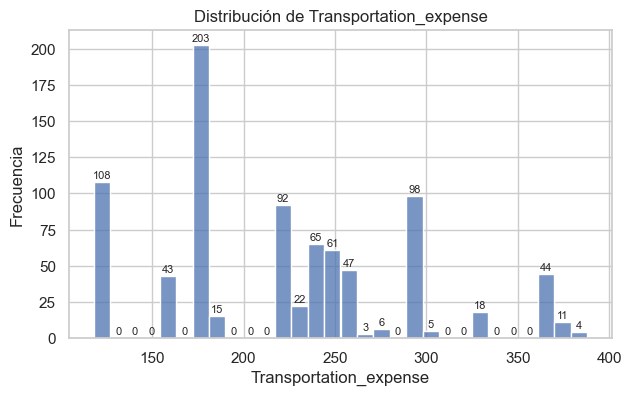

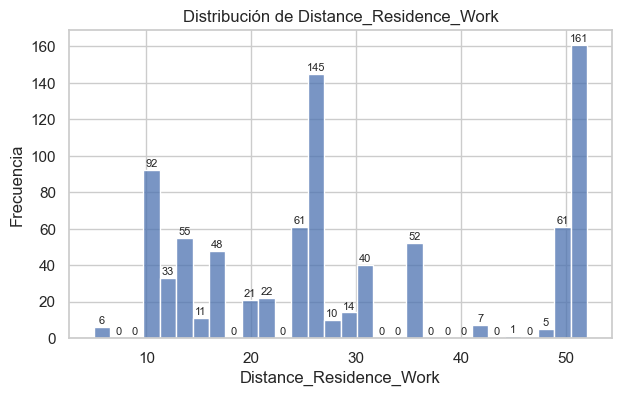

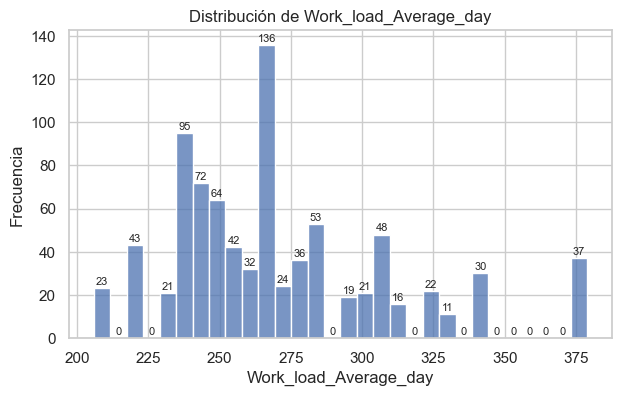

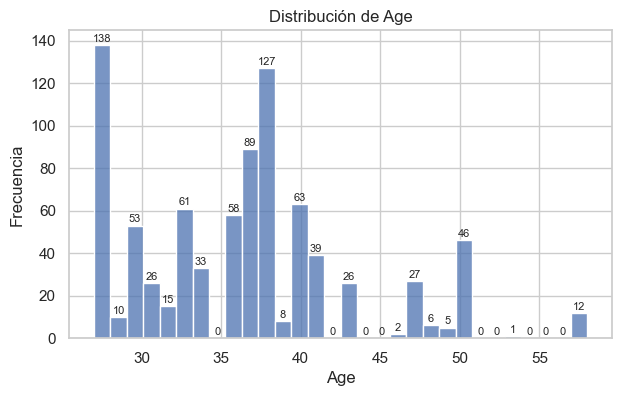

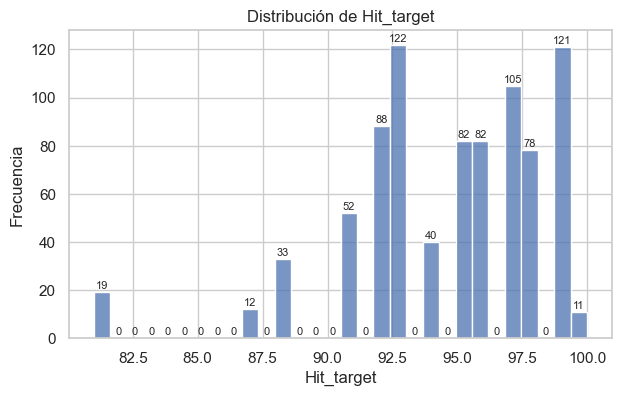

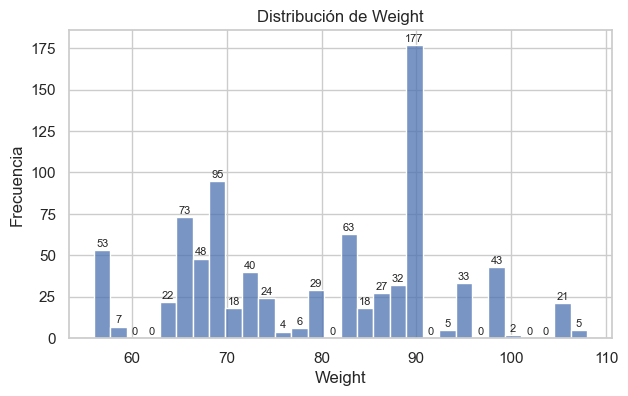

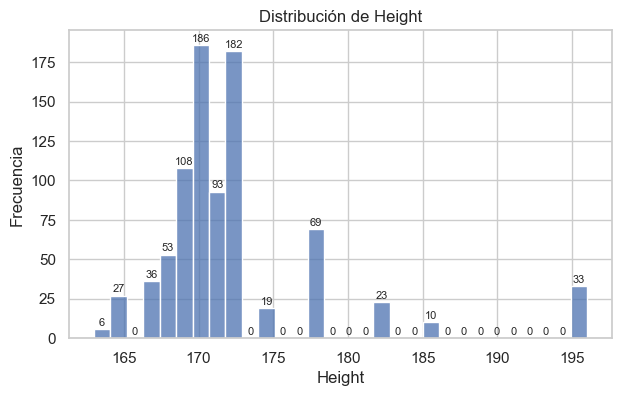

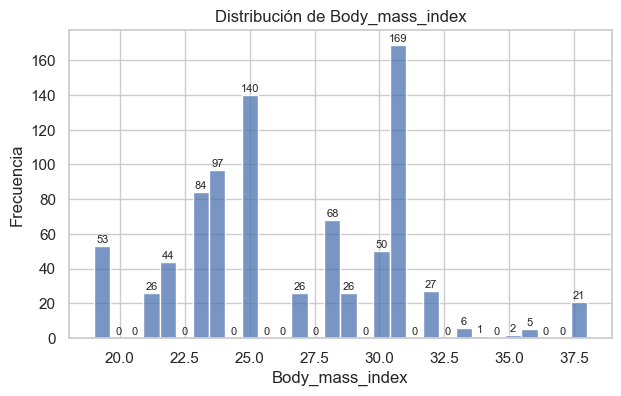

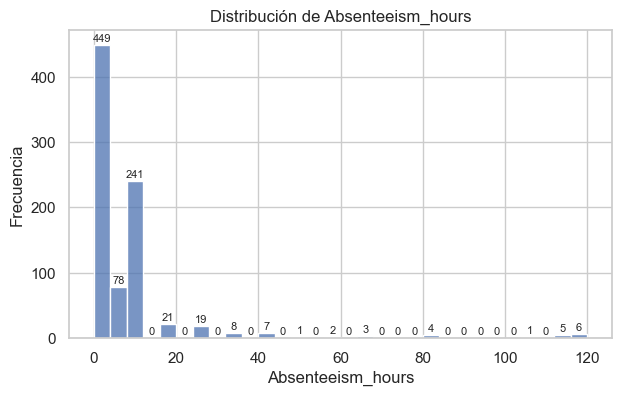

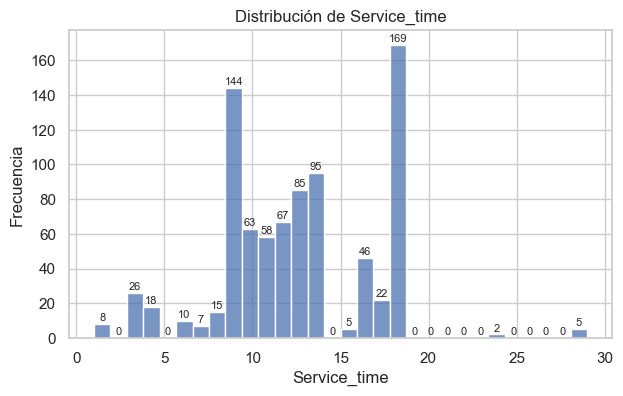

In [ ]:
for col in variables_continuas:
    plt.figure(figsize=(7, 4))
    ax =sns.histplot(data=df, x=col, bins=30)

    ax.bar_label(ax.containers[0], padding=1, fontsize=8)

    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

#### Distribución númericas discretas

,Son,frecuencia,porcentaje
0,0,339,40.12
1,1,258,30.53
2,2,183,21.66
3,3,18,2.13
4,4,47,5.56


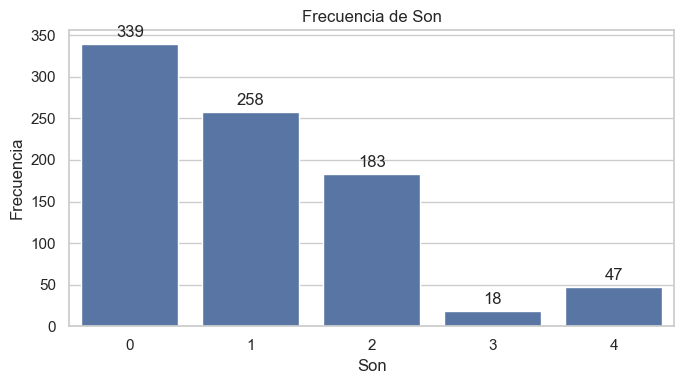

,Pet,frecuencia,porcentaje
0,0,525,62.13
1,1,161,19.05
2,2,107,12.66
3,4,37,4.38
4,5,6,0.71
5,8,9,1.07


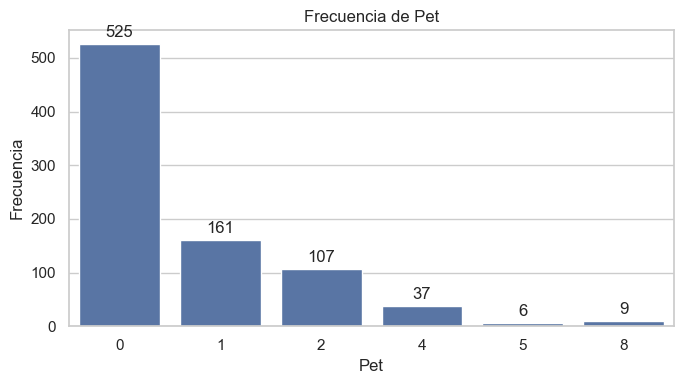

In [ ]:
for col in variables_discretas:
    tabla_frecuencia = (
        df[col]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis(col)
        .reset_index(name="frecuencia")
    )
    
    tabla_frecuencia["porcentaje"] = (
        tabla_frecuencia["frecuencia"] / len(df) * 100
    ).round(2)
    
    display(tabla_frecuencia)
    
    plt.figure(figsize=(7, 4))
    ax = sns.barplot(data=tabla_frecuencia, x=col, y="frecuencia")
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3)

    plt.title(f"Frecuencia de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

#### Detección de Outliers (continuas)

##### Resumen cuantitativo de outliers

In [ ]:
resumen_outliers = []

for col in variables_continuas:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    mascara = (df[col] < limite_inferior) | (df[col] > limite_superior)

    resumen_outliers.append({
        "variable": col,
        "limite_inferior": round(limite_inferior, 2),
        "limite_superior": round(limite_superior, 2),
        "n_outliers": int(mascara.sum()),
        "porcentaje_outliers": round(mascara.mean() * 100, 2),
        "min": df[col].min(),
        "max": df[col].max()
    })

resumen_outliers = pd.DataFrame(resumen_outliers).sort_values("porcentaje_outliers", ascending=False)
resumen_outliers


,variable,limite_inferior,limite_superior,n_outliers,porcentaje_outliers,min,max
6,Height,164.50,176.50,141,16.69,163.000,196.000
8,Absenteeism_hours,-7.00,17.00,56,6.63,0.000,120.000
2,Work_load_Average_day,183.69,345.55,37,4.38,205.917,378.884
4,Hit_target,87.00,103.00,19,2.25,81.000,100.000
3,Age,17.50,53.50,12,1.42,27.000,58.000
9,Service_time,-1.50,26.50,5,0.59,1.000,29.000
0,Transportation_expense,57.50,381.50,4,0.47,118.000,388.000
1,Distance_Residence_Work,-33.50,98.50,0,0.00,5.000,52.000
5,Weight,39.00,119.00,0,0.00,56.000,108.000
7,Body_mass_index,13.50,41.50,0,0.00,19.000,38.000


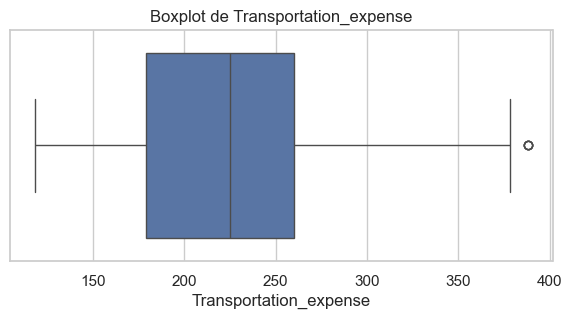

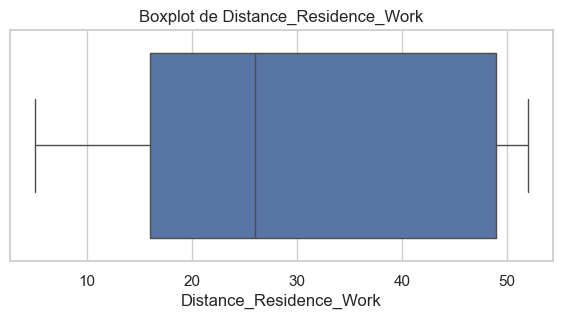

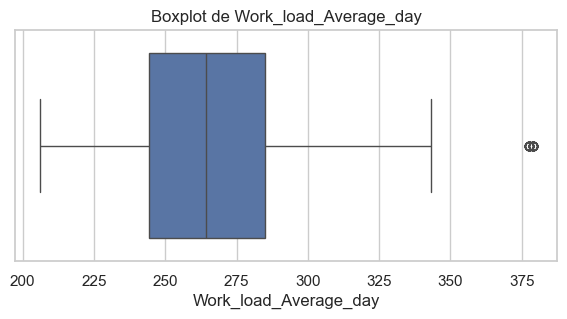

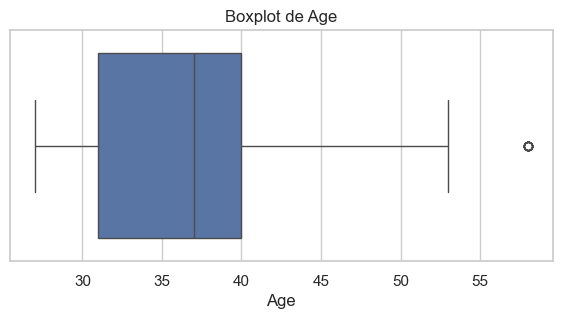

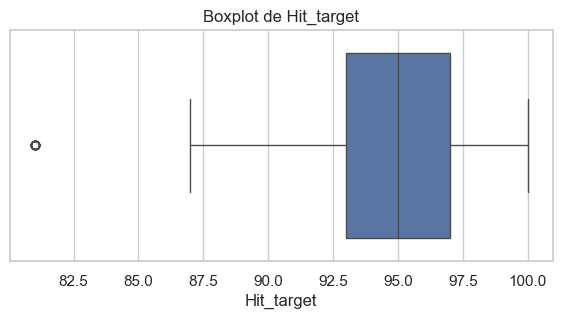

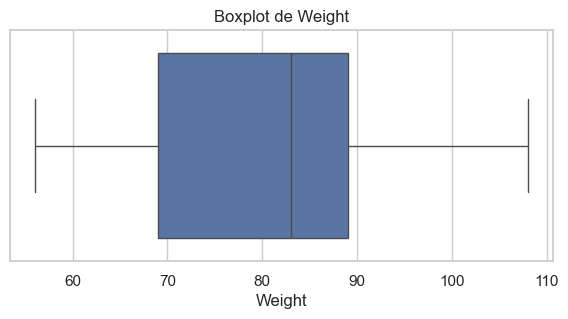

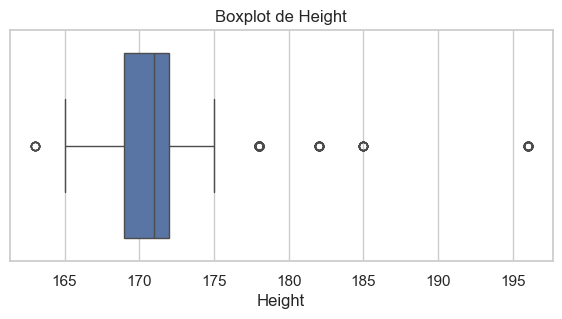

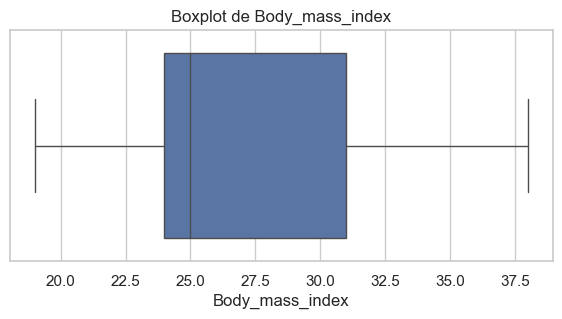

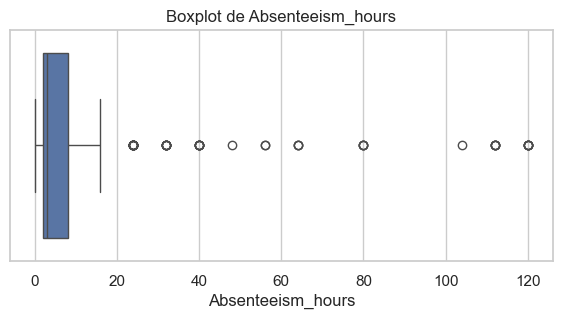

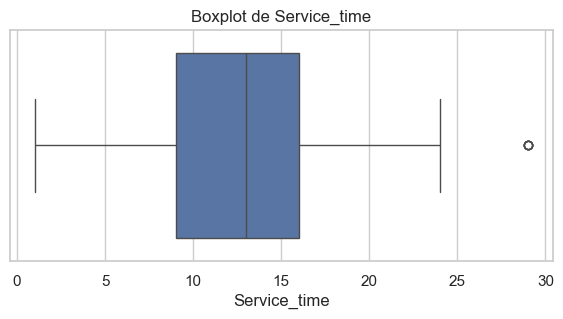

In [ ]:
for col in variables_continuas:
    plt.figure(figsize=(7, 3))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

#### Frecuencias Categóricas

# PENDIENTE VALIDAR SEASONS CON CONVERSIÓN DATA CLEANING

In [ ]:
ordenes_categoricas = {
    "Month_absence": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    "Day_week": [2, 3, 4, 5, 6],
    "Seasons": [1, 2, 3, 4],
    "Education": [1, 2, 3, 4]

}

diccionario_categoricas = {
    "Month_absence": {
        0:"Sin mes",
        1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr",
        5: "May", 6: "Jun", 7: "Jul", 8: "Ago",
        9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"
    },
    "Day_week": {
        2: "Lun", 3: "Mar", 4: "Mié", 5: "Jue", 6: "Vie"
    },
    "Seasons": {
        1: "Verano", 2: "Otoño", 3: "Invierno", 4: "Primavera"
    },
    "Education": {
        1: "Secundaria", 2: "Graduado", 3: "Postgrado", 4: "Master o doctorado"
    }

}

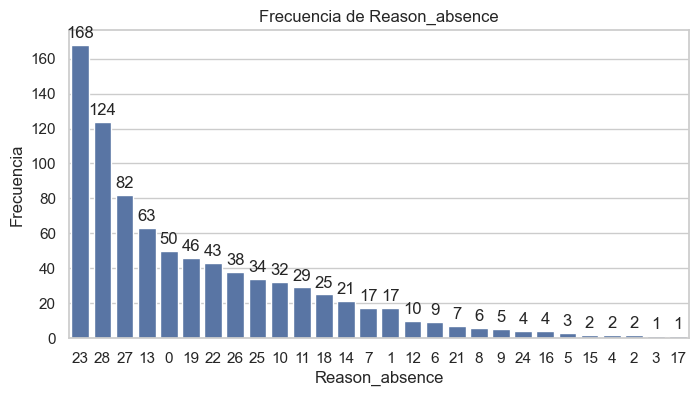

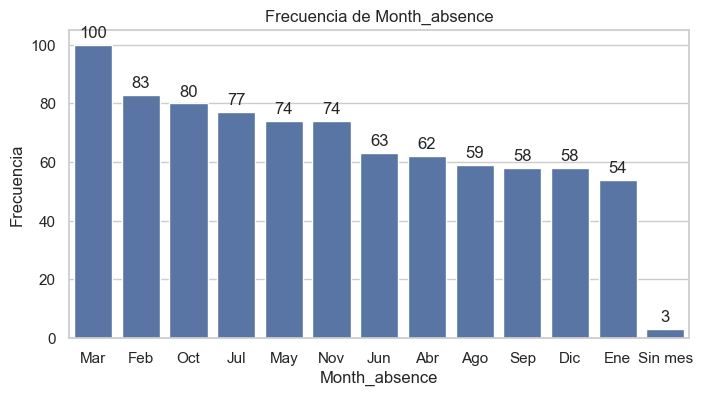

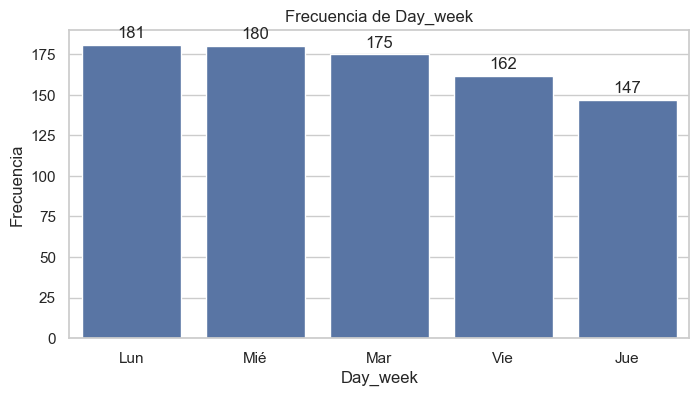

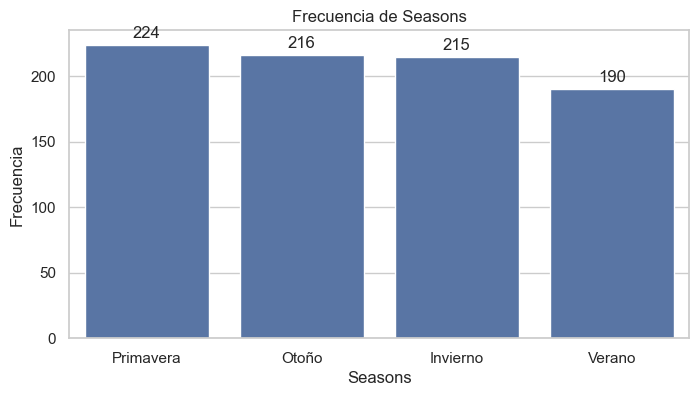

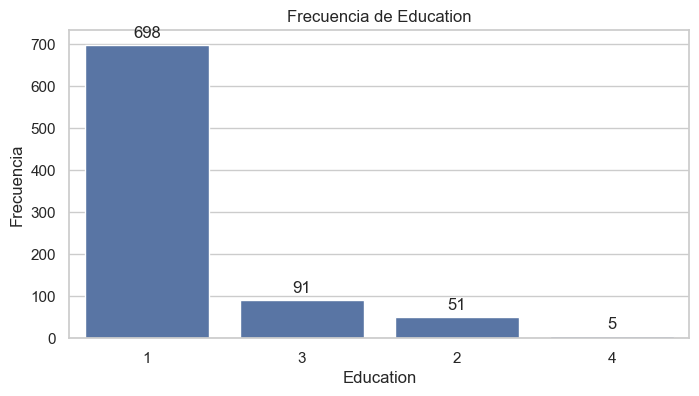

In [ ]:
for col in variables_categoricas:
    plt.figure(figsize=(8, 4))
    orden = df[col].value_counts().index
    ax =sns.countplot(data=df, x=col, order=orden)
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3)

    if col in diccionario_categoricas:
        labels = [diccionario_categoricas[col].get(x, x) for x in orden]
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels)

    plt.title(f"Frecuencia de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=0)
    plt.show()

#### Porcentaje Booleanas

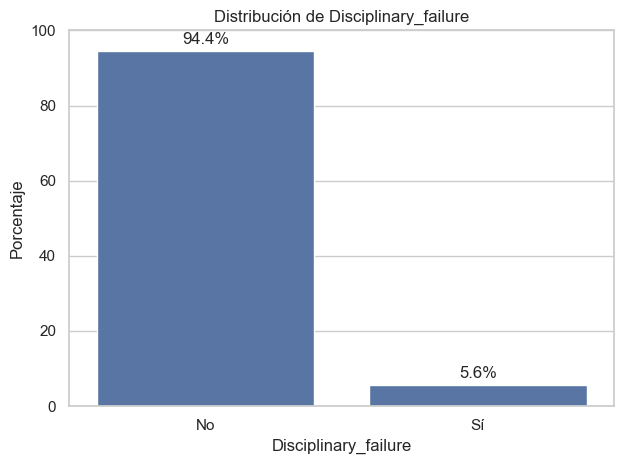

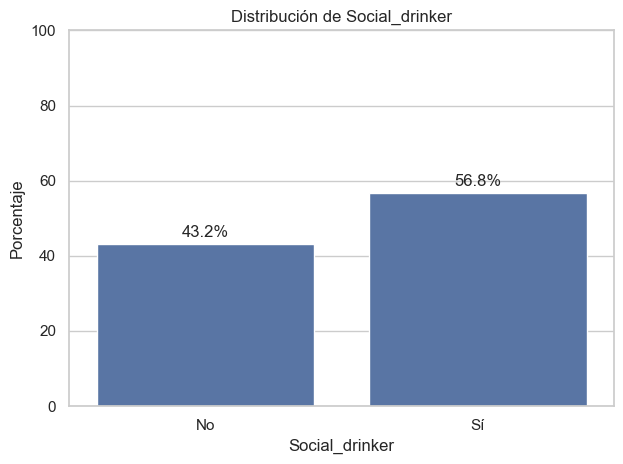

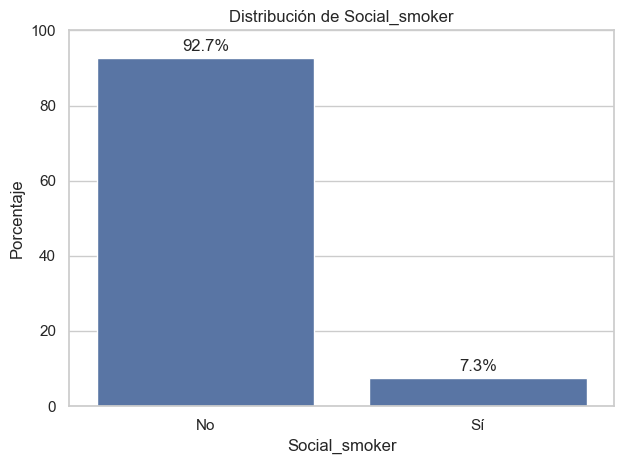

In [ ]:
for col in variables_booleanas:
    serie = pd.to_numeric(df[col], errors="coerce")
    tabla = (
        serie
        .map({0: "No", 1: "Sí"})
        .value_counts(normalize=True)
        .mul(100)
        .reindex(["No", "Sí"])
        .reset_index()
    )

    tabla.columns = [col, "porcentaje"]

    ax = sns.barplot(data=tabla, x=col, y="porcentaje")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3)

    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Porcentaje")
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

#### Relaciones entre variables

##### Gráficos de dispersión

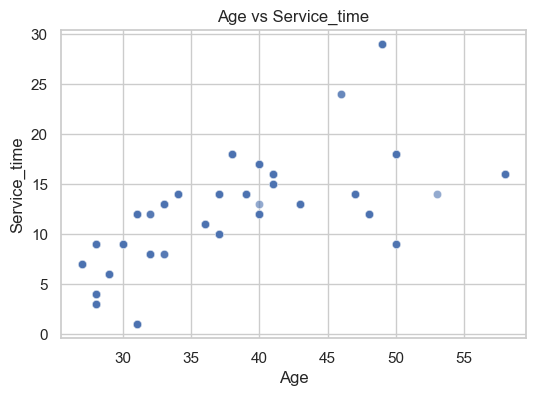

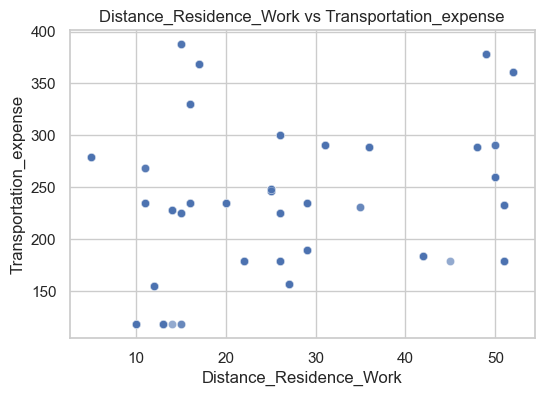

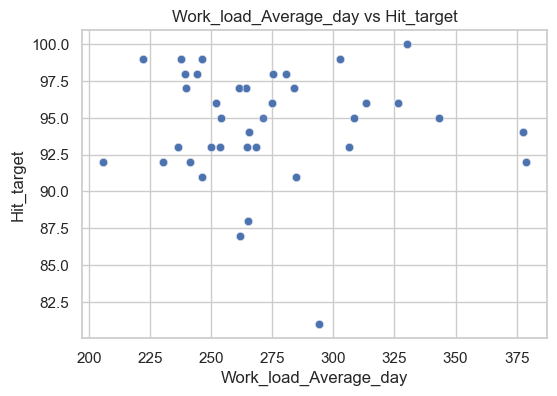

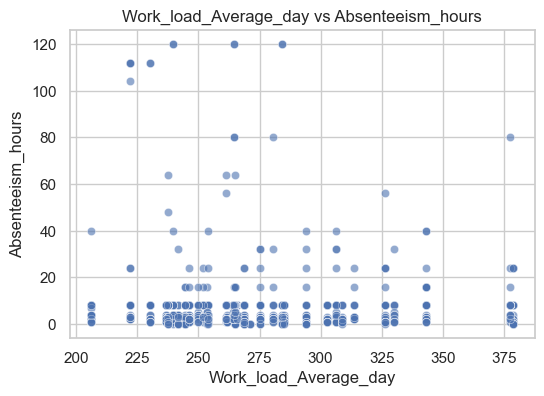

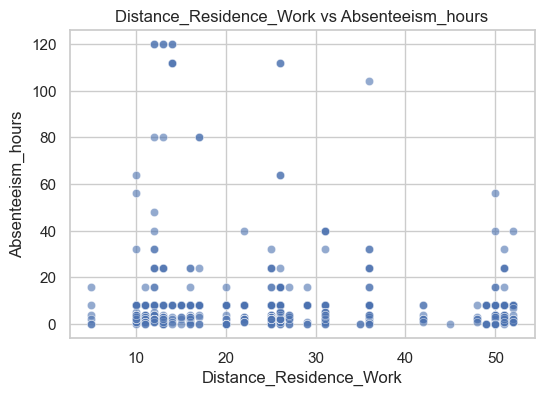

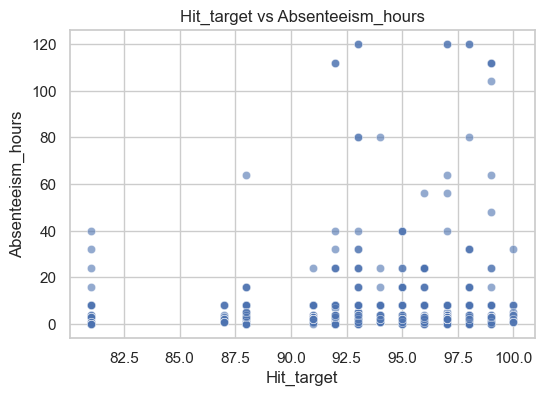

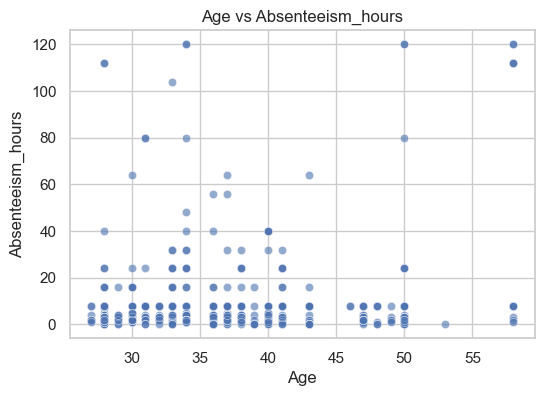

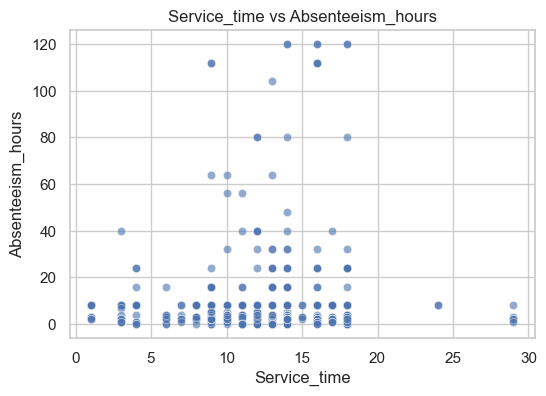

In [ ]:
pares_dispersion = [
    ("Age", "Service_time"),
    ("Distance_Residence_Work", "Transportation_expense"),
    ("Work_load_Average_day", "Hit_target"),
    ("Work_load_Average_day", "Absenteeism_hours"),
    ("Distance_Residence_Work", "Absenteeism_hours"),
    ("Hit_target", "Absenteeism_hours"),
    ("Age", "Absenteeism_hours"),
    ("Service_time", "Absenteeism_hours")
]

for x, y in pares_dispersion:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=x, y=y, alpha=0.6)
    plt.title(f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

##### Matriz de correlación

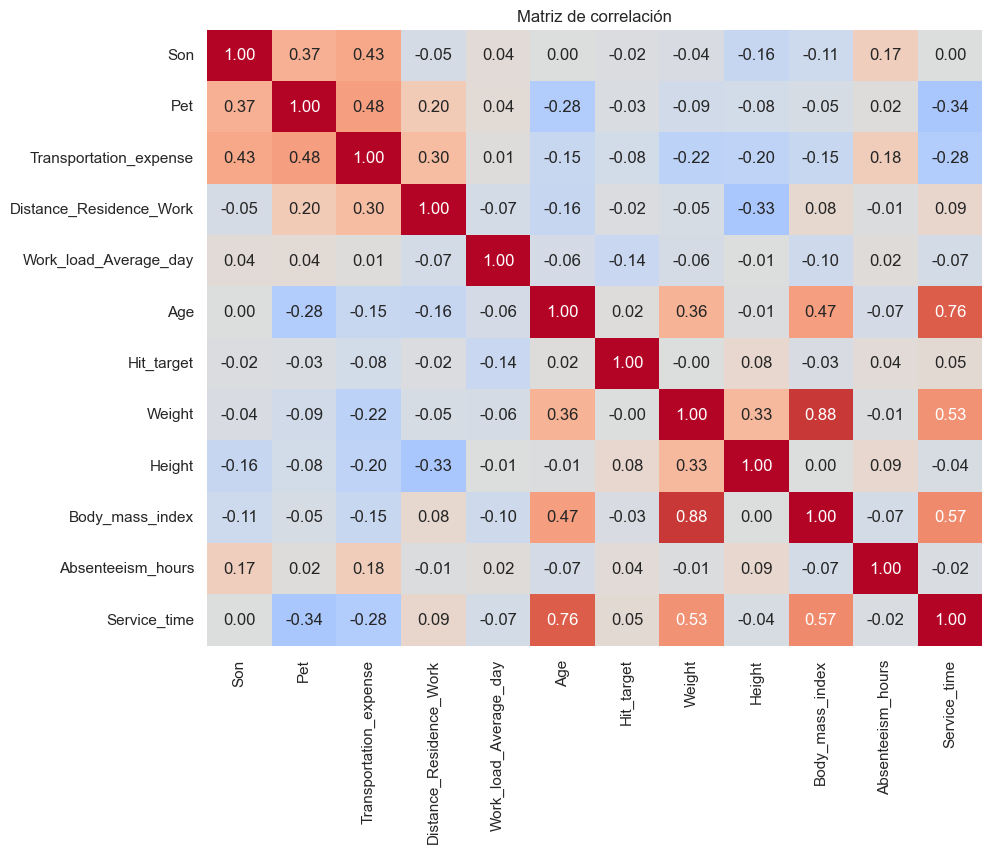

In [ ]:
variables_correlacion = variables_discretas + variables_continuas

matriz_correlacion = df[variables_correlacion].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    cbar=False
)
plt.title("Matriz de correlación")
plt.show()

##### Cruce de categóricas


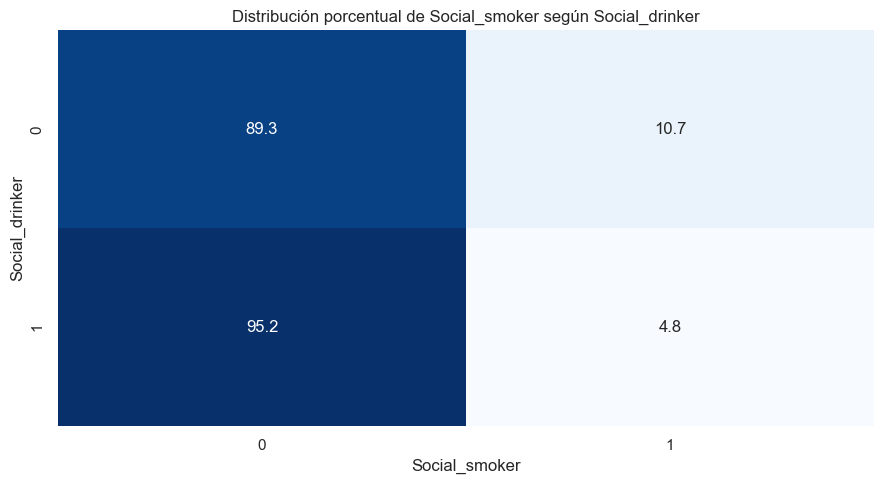

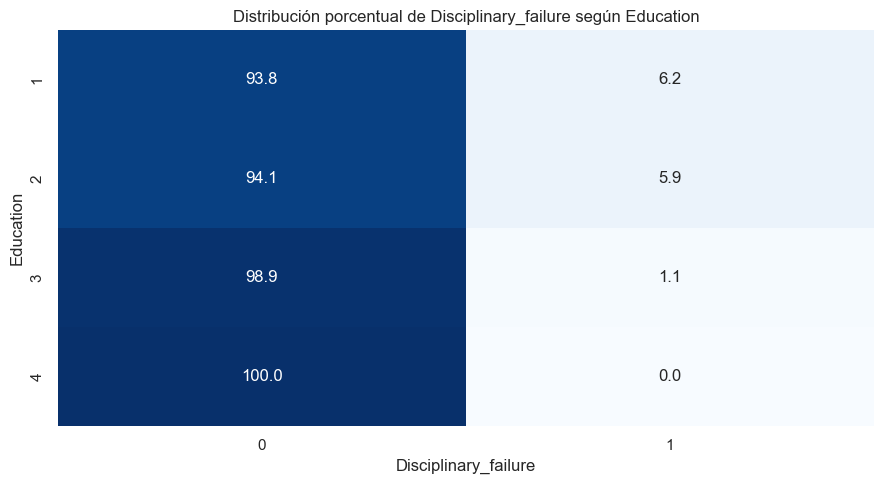

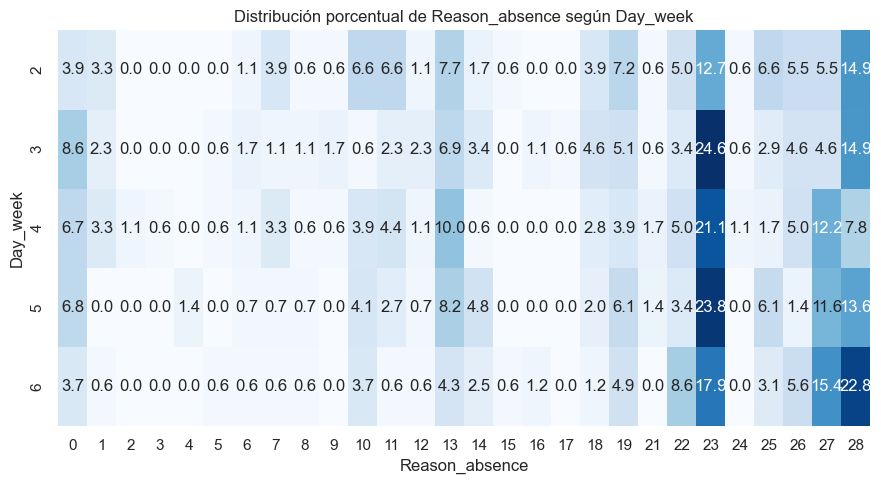

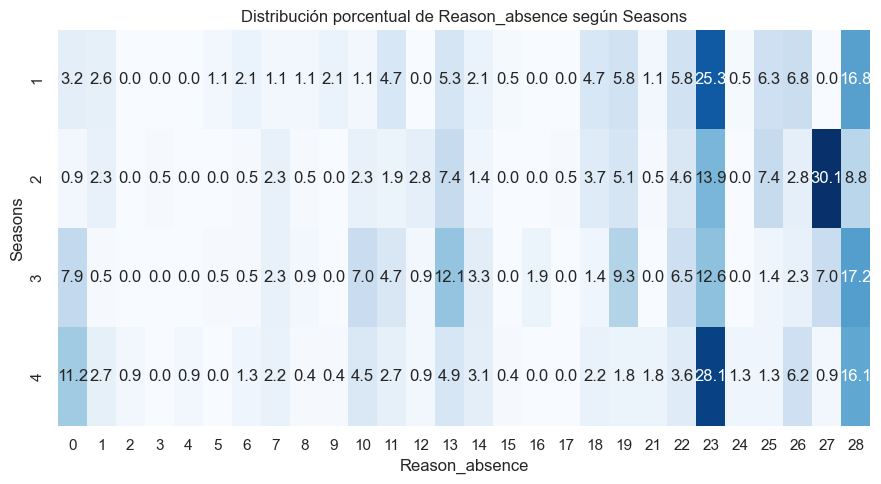

In [ ]:
pares_categoricos = [
    ("Social_drinker", "Social_smoker"),
    ("Education", "Disciplinary_failure"),
    ("Day_week", "Reason_absence"),
    ("Seasons", "Reason_absence")
]

for col1, col2 in pares_categoricos:
    tabla_porcentaje = pd.crosstab(
        df[col1],
        df[col2],
        normalize="index"
    ) * 100

    plt.figure(figsize=(9, 5))
    sns.heatmap(
        tabla_porcentaje,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"Distribución porcentual de {col2} según {col1}")
    plt.xlabel(col2)
    plt.ylabel(col1)
    plt.tight_layout()
    plt.show()

In [ ]:
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape

    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

asociaciones_categoricas = []

variables_asociaciones = variables_categoricas + variables_booleanas

for i, col1 in enumerate(variables_asociaciones):
    for col2 in variables_asociaciones[i+1:]:
        asociaciones_categoricas.append({
            "variable_1": col1,
            "variable_2": col2,
            "cramers_v": cramers_v(df[col1], df[col2])
        })

asociaciones_categoricas = pd.DataFrame(asociaciones_categoricas)

asociaciones_categoricas.sort_values("cramers_v", ascending=False)

,variable_1,variable_2,cramers_v
4,Reason_absence,Disciplinary_failure,0.967712
8,Month_absence,Seasons,0.899459
23,Education,Social_drinker,0.471229
6,Reason_absence,Social_smoker,0.369058
5,Reason_absence,Social_drinker,0.358580
2,Reason_absence,Seasons,0.355759
24,Education,Social_smoker,0.354831
3,Reason_absence,Education,0.310744
0,Reason_absence,Month_absence,0.264459
10,Month_absence,Disciplinary_failure,0.242830


##### Cruce categóricas, numéricas

C:\Users\vanes\AppData\Local\Temp\ipykernel_10504\4265099210.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(cat)[num]


,count,mean,median,std
Education,,,,
1,698,94.50,95.0,3.76
2,51,96.02,96.0,2.52
3,91,94.97,96.0,3.67
4,5,98.60,99.0,0.89


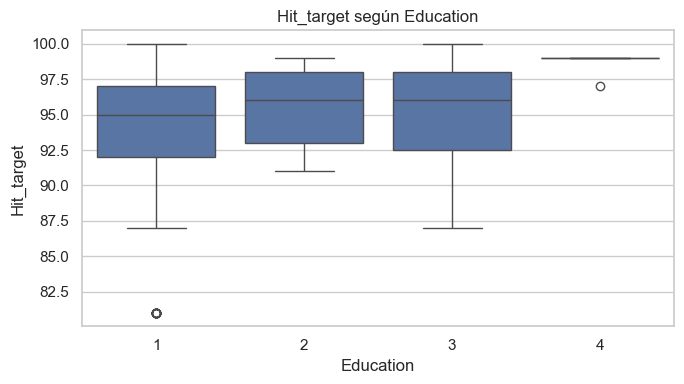

C:\Users\vanes\AppData\Local\Temp\ipykernel_10504\4265099210.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(cat)[num]


,count,mean,median,std
Education,,,,
1,698,13.07,13.0,4.13
2,51,9.37,4.0,6.88
3,91,10.30,9.0,2.38
4,5,15.00,15.0,0.00


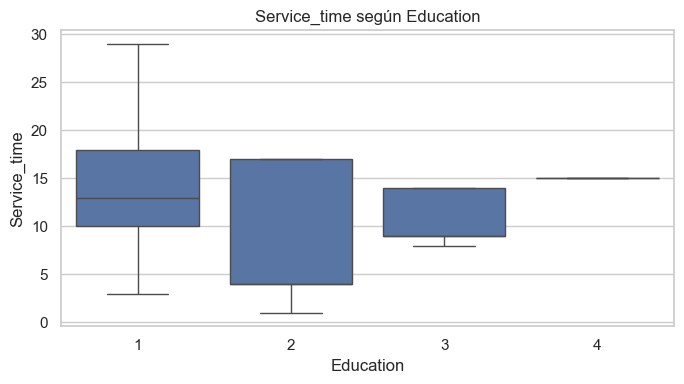

C:\Users\vanes\AppData\Local\Temp\ipykernel_10504\4265099210.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(cat)[num]


,count,mean,median,std
Education,,,,
1,698,8.03,3.0,17.07
2,51,6.73,8.0,6.92
3,91,5.36,3.0,7.56
4,5,4.80,3.0,2.95


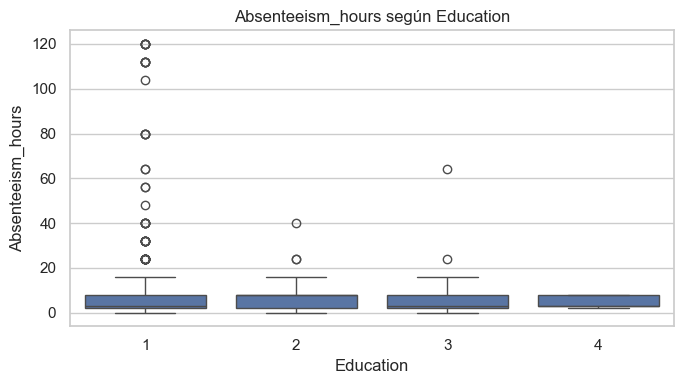

,count,mean,median,std
Disciplinary_failure,,,,
0,798,8.1,3.0,16.17
1,47,0.0,0.0,0.00


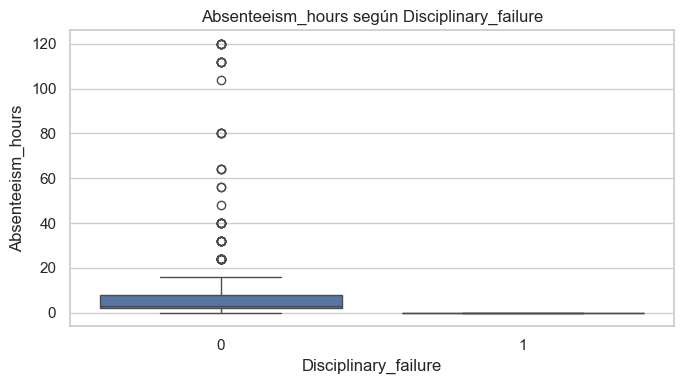

,count,mean,median,std
Disciplinary_failure,,,,
0,798,94.79,95.0,3.58
1,47,92.55,92.0,5.02


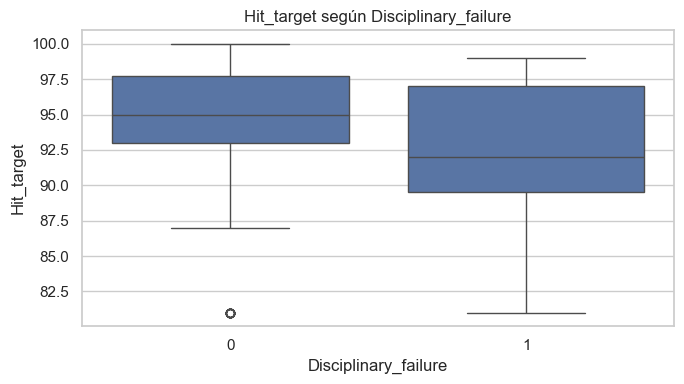

,count,mean,median,std
Social_drinker,,,,
0,365,25.01,24.0,4.02
1,480,27.91,30.0,4.04


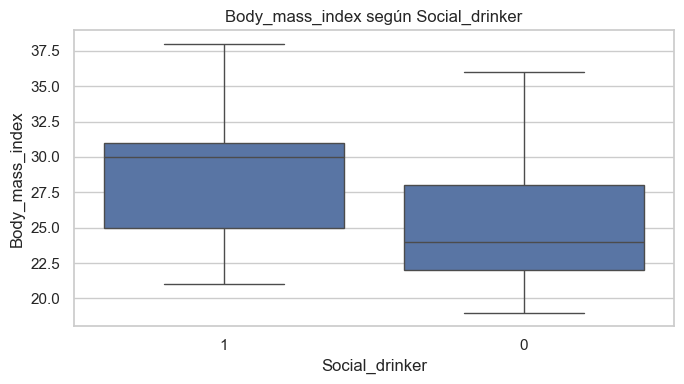

,count,mean,median,std
Social_smoker,,,,
0,783,7.77,3.0,16.22
1,62,6.16,3.5,9.52


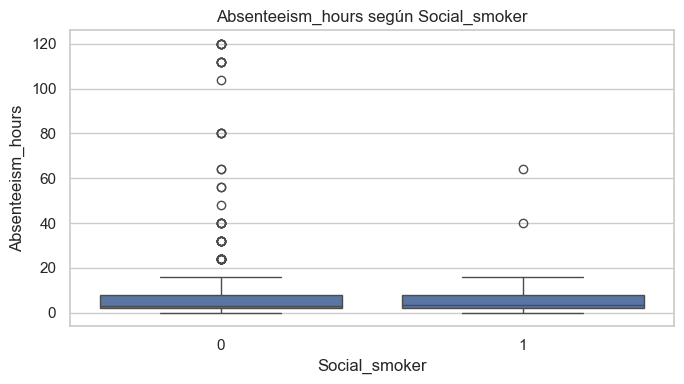

In [ ]:
cruces = [
    ("Education", "Hit_target"),
    ("Education", "Service_time"),
    ("Education", "Absenteeism_hours"),
    ("Disciplinary_failure", "Absenteeism_hours"),
    ("Disciplinary_failure", "Hit_target"),
    ("Social_drinker", "Body_mass_index"),
    ("Social_smoker", "Absenteeism_hours")
]

for cat, num in cruces:
    display(
        df.groupby(cat)[num]
        .agg(["count", "mean", "median", "std"])
        .round(2)
    )

    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x=cat, y=num)
    plt.title(f"{num} según {cat}")
    plt.tight_layout()
    plt.show()

### Conclusiones

#### Conclusiones Generales

Se mantiene la validez de las conclusiones del resumen 2026-06-29_EDA.
Hay más registros pero todas las tendencias se mantienen.

Resultados una vez se han eliminado los duplicados y vuelto a ejecutar:

- Total registros: 845 (+105 nuevos)  
- Total: 136 empleados (+100 nuevos)  
- Sin nulos  
- Sigue apareciendo month=0  
- % duplicados se mantiene (4,62% vs 4,59%)  
- Variables numéricas mantienen min y max.  
- Variables categóricas no han sumados categorias nuevas, y frecuencia top se mantiene en cada una.  
- Las distribuciones de todas las variables se mantienen. De hecho, sólo se suman registros a los valores existentes manteniendo la frecuencia general de cada valor.  
- Work_load_Average_day tiene alguns cambios con sus nuevos registros.  



<!-- #### Conclusiones Relaciones

Correlaciones fuertes o relevantes
* Weight y Body_mass_index: 0.89
Normal dado que el IMC depende directamente del peso.

* Age y Service_time: 0.76
Empleados de mayor edad tienden a tener más tiempo de servicio.

    * Body_mass_index y Service_time: 0.56

    * Age y Body_mass_index: 0.48

    * Weight y Service_time: 0.53

* Son y Transportation_expense: 0.42
* Pet y Transportation_expense: 0.47
Empleado con hijos o mascotas tienden a gastar más en transporte.


Relaciones negativas
* Pet y Service_time: -0.34
Empleados con más tiempo de servicio tienden a tener menos mascotas. 
* Pet y Age: -0.28
Empleados con más edad tienden a tener menos mascotas. 

* Transportation_expense y Service_time: -0.28
A mayor tiempo de servicio, menor gasto de transporte. Podría deberse a perfiles de empleados, ubicación o antigüedad.


Cruces de categóricas

* Reason_absence vs Disciplinary_failure: 0.962
 Probablemente porque ciertos motivos de ausencia están directamente ligados a fallo disciplinario o ausencia injustificada. Revisaría la tabla cruzada: puede haber una categoría casi exclusiva.

* Education vs Social_drinker: 0.472
Asociación moderada. El consumo social de alcohol varía según nivel educativo.

* Education vs Social_smoker: 0.364
Asociación moderada-baja. El hábito de fumar también cambia según educación, aunque menos que beber.

Estas sugieren que los motivos de ausencia no se distribuyen igual según hábitos sociales o estación:
 
* Reason_absence vs Social_smoker: 0.356
* Reason_absence vs Seasons: 0.347
* Reason_absence vs Social_drinker: 0.346 -->
